In [1]:
import pandas as pd

redwine = pd.read_csv("winequality-red.csv", sep=";")
X, y = redwine.iloc[:, :-1], redwine.iloc[:, -1]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [2]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

model = Sequential()
model.add(Input(shape=(11,)))
model.add(Dense(100, activation="sigmoid"))
model.add(Dense(200, activation="relu"))
model.add(Dense(50, activation="tanh"))
model.add(Dense(10, activation="softmax"))
model.summary()

I0000 00:00:1778985000.883766  292170 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778985000.927317  292170 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778985001.863864  292170 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1778985002.451516  292170 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries co

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │        10,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,960 (124.84 KB)

 Trainable params: 31,960 (124.84 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint

checkpoint = ModelCheckpoint("best_model.keras", save_best_only=True)
tensorboard = TensorBoard(log_dir="./logs", histogram_freq=1, embeddings_freq=1)

In [13]:
# history = model.fit(X_train, y_train,
#                    batch_size=200, epochs=300)
history = model.fit(X_train, y_train,
                    batch_size=200, epochs=300, callbacks=[checkpoint, tensorboard],
                    validation_data=(X_test, y_test))

Epoch 1/300


I0000 00:00:1778985457.466587  292877 service.cc:153] XLA service 0x724b74031db0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778985457.466623  292877 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5090, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1778985457.505338  292877 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778985457.615925  292877 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1778985457.636751  292877 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1940__.14
I0000 00:00:1778985457.653912  292877 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I

1/6 ━━━━━━━━━━━━━━━━━━━━ 29s 6s/step - accuracy: 0.1450 - loss: 2.4949

I0000 00:00:1778985461.776119  292877 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1778985461.927473  292875 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1940__.14
I0000 00:00:1778985462.538153  292875 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778985463.004449  294409 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1778985463.038750  294423 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1778985463.169510  

6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 993ms/step - accuracy: 0.3003 - loss: 1.7672 - val_accuracy: 0.3975 - val_loss: 1.2788
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4437 - loss: 1.2298 - val_accuracy: 0.3900 - val_loss: 1.2205
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4579 - loss: 1.1880 - val_accuracy: 0.5300 - val_loss: 1.1662
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4896 - loss: 1.1621 - val_accuracy: 0.4325 - val_loss: 1.1667
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4854 - loss: 1.1473 - val_accuracy: 0.5400 - val_loss: 1.1458
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4929 - loss: 1.1427 - val_accuracy: 0.5350 - val_loss: 1.1336
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4829 - loss: 1.1351 - val_accuracy: 0.5325 - val_loss: 1.1280
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4937 - loss: 1.1286 - val_accuracy: 0.5425 - val_loss: 1.1193
Ep

In [14]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"loss: {loss:.4f}, accuracy: {accuracy:.4f}")

I0000 00:00:1778985615.088832  292874 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778985615.326825  528005 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1778985616.261999  528270 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1778985616.488485  292877 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


loss: 0.9912, accuracy: 0.5800


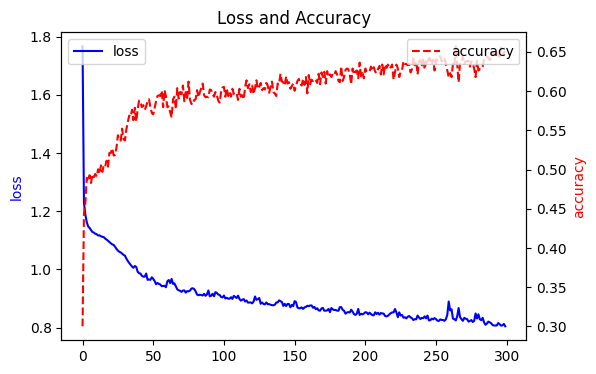

In [15]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(history.history["loss"], 'b-', label="loss")
ax1.set_ylabel("loss", color="b")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(history.history["accuracy"], 'r--', label="accuracy")
ax2.set_ylabel("accuracy", color="r")
ax2.legend(loc="upper right")
plt.title("Loss and Accuracy")
plt.show()

In [16]:
import numpy as np
y_pred = model.predict(X_test)
print("predicted:", np.argmax(y_pred[:5], axis=1))
print("actual   :", y_test[:5].values)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
predicted: [5 6 6 5 5]
actual   : [5 6 6 5 6]
